# Web/Text Mining and Sentiment Analysis: *Titanic (1997 film)*

This notebook extracts and analyzes selected sections from the Wikipedia page for *Titanic (1997 film)*:

- Title  
- Introductory Paragraph  
- History / Production  
- Main Content  
- References  

Then it applies sentiment analysis using **VADER** and compares the results with **TextBlob**. It also visualizes sentiment scores, polarity over text order, and generates a WordCloud.


## 1. Import libraries

The main tools used are:

- `requests` to download the webpage
- `BeautifulSoup` to parse HTML
- `pandas` to organize the extracted text
- `VADER` for sentiment analysis
- `TextBlob` for comparison
- `matplotlib` for charts
- `WordCloud` for word visualization


In [3]:
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize

from textblob import TextBlob

# Download NLTK resources 
nltk.download("vader_lexicon")
nltk.download("punkt")
try:
    nltk.download("punkt_tab")
except:
    pass


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\inare\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\inare\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\inare\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## 2. Fetch the Wikipedia page

The page used in this project is the Wikipedia article for *Titanic (1997 film)*. Wikipedia is a good source for this assignment because it has clear article sections such as title, introduction, production, reception, and references.


In [2]:
url = "https://en.wikipedia.org/wiki/Titanic_(1997_film)"

headers = {
    "User-Agent": "Mozilla/5.0 (compatible; student-web-mining-project/1.0)"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")
print("Page downloaded successfully.")


Page downloaded successfully.


## 3. Helper functions for text extraction

The functions below clean extracted text and collect section content from the Wikipedia page.  
For this specific article, the assignment's **History** section is treated as **Production**, because the page does not have a heading literally named “History.” The Production section explains the background, filming, and development history of the film.


In [4]:
def clean_text(text):
    """Clean extra spaces, citation brackets, and newline characters."""
    text = re.sub(r"\[\s*\d+\s*\]", "", text)     # remove citations like [1]
    text = re.sub(r"\[Note\s*\d+\]", "", text)   # remove notes like [Note 1]
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def get_page_title(soup):
    title_tag = soup.find("h1")
    return clean_text(title_tag.get_text(" ", strip=True)) if title_tag else ""


def get_intro_paragraphs(soup, max_paragraphs=3):
    """Extract introductory paragraphs before the first major section."""
    content = soup.find("div", id="mw-content-text")
    paragraphs = []

    for p in content.find_all("p", recursive=True):
        text = clean_text(p.get_text(" ", strip=True))
        if len(text) > 80:
            paragraphs.append(text)
        if len(paragraphs) >= max_paragraphs:
            break

    return " ".join(paragraphs)


def get_section_text(soup, section_title):
    """
    Extract text from a section by its visible heading.
    Collect paragraphs and list items until the next h2 heading.
    """
    heading = None

    for h in soup.find_all(["h2", "h3"]):
        heading_text = clean_text(h.get_text(" ", strip=True)).replace("[edit]", "")
        if heading_text.lower() == section_title.lower():
            heading = h
            break

    if heading is None:
        return ""

    texts = []
    for sibling in heading.find_next_siblings():
        if sibling.name == "h2":
            break
        if sibling.name in ["p", "ul", "ol"]:
            text = clean_text(sibling.get_text(" ", strip=True))
            if text:
                texts.append(text)
        elif sibling.name in ["h3", "h4"]:
            subtitle = clean_text(sibling.get_text(" ", strip=True)).replace("[edit]", "")
            if subtitle:
                texts.append(subtitle)

    return " ".join(texts)


def get_references_text(soup, max_refs=20):
    """Extract a sample of references from the References section."""
    references_heading = None

    for h in soup.find_all("h2"):
        heading_text = clean_text(h.get_text(" ", strip=True)).replace("[edit]", "")
        if heading_text.lower() == "references":
            references_heading = h
            break

    if references_heading is None:
        return ""

    refs = []
    for sibling in references_heading.find_next_siblings():
        if sibling.name == "h2":
            break
        for li in sibling.find_all("li"):
            ref_text = clean_text(li.get_text(" ", strip=True))
            if ref_text:
                refs.append(ref_text)
            if len(refs) >= max_refs:
                break
        if len(refs) >= max_refs:
            break

    return " ".join(refs)


## 4. Extract required sections

The required sections are extracted as follows:

- **Title**: article title from the `<h1>` tag  
- **Introductory Paragraph**: first few meaningful paragraphs before the main sections  
- **History**: represented by the article's **Production** section  
- **Main Content**: major article sections such as Plot, Cast, Release, Reception, Accolades, and Legacy  
- **References**: sample references from the References section  


In [5]:
title = get_page_title(soup)
intro = get_intro_paragraphs(soup)

# The article does not have a literal "History" heading, so Production is used as the history/background section.
history = get_section_text(soup, "Production")

main_section_names = [
    "Plot",
    "Cast",
    "Soundtrack",
    "Release",
    "Reception",
    "Accolades",
    "Legacy and re-releases",
    "Representation in other media"
]

main_content_parts = []
for section in main_section_names:
    section_text = get_section_text(soup, section)
    if section_text:
        main_content_parts.append(section_text)

main_content = " ".join(main_content_parts)
references = get_references_text(soup, max_refs=20)

sections = {
    "Title": title,
    "Introductory Paragraph": intro,
    "History / Production": history,
    "Main Content": main_content,
    "References": references
}

for name, text in sections.items():
    print(f"\n--- {name} ---")
    print(text[:700], "..." if len(text) > 700 else "")



--- Title ---
Titanic (1997 film) 

--- Introductory Paragraph ---
Titanic is a 1997 American epic historical romance film written and directed by James Cameron . Incorporating both historical and fictional aspects, it is based on accounts of the sinking of RMS Titanic in 1912. Leonardo DiCaprio and Kate Winslet star as members of different social classes who fall in love during the ship's ill-fated maiden voyage. The ensemble cast includes Billy Zane , Kathy Bates , Frances Fisher , Bernard Hill , Jonathan Hyde , Danny Nucci , David Warner and Bill Paxton . Cameron's inspiration came from his fascination with shipwrecks . He felt a love story interspersed with human loss would be essential to convey the emotional impact of the disaster. Production began on ...

--- History / Production ---
 

--- Main Content ---
 

--- References ---
 


## 5. Organize extracted sections into a DataFrame

This table makes it easier to compare section length and sentiment scores later.


In [6]:
df = pd.DataFrame([
    {
        "Section": name,
        "Text": text,
        "Character_Count": len(text),
        "Word_Count": len(text.split())
    }
    for name, text in sections.items()
])

df


,Section,Text,Character_Count,Word_Count
0,Title,Titanic (1997 film),19,3
1,Introductory Paragraph,Titanic is a 1997 American epic historical rom...,2427,403
2,History / Production,,0,0
3,Main Content,,0,0
4,References,,0,0


## 6. Apply VADER sentiment analysis

VADER returns four scores:

- `neg`: negative score  
- `neu`: neutral score  
- `pos`: positive score  
- `compound`: overall sentiment score from -1 to +1  

For this project, the **compound score** is used as the main sentiment score.


In [7]:
sia = SentimentIntensityAnalyzer()

def vader_label(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

vader_results = []

for section, text in sections.items():
    score = sia.polarity_scores(text)
    vader_results.append({
        "Section": section,
        "VADER_Negative": score["neg"],
        "VADER_Neutral": score["neu"],
        "VADER_Positive": score["pos"],
        "VADER_Compound": score["compound"],
        "VADER_Label": vader_label(score["compound"])
    })

vader_df = pd.DataFrame(vader_results)
vader_df


,Section,VADER_Negative,VADER_Neutral,VADER_Positive,VADER_Compound,VADER_Label
0,Title,0.000,1.000,0.000,0.0000,Neutral
1,Introductory Paragraph,0.018,0.781,0.202,0.9981,Positive
2,History / Production,0.000,0.000,0.000,0.0000,Neutral
3,Main Content,0.000,0.000,0.000,0.0000,Neutral
4,References,0.000,0.000,0.000,0.0000,Neutral


## 7. Compare VADER with TextBlob

TextBlob provides:

- `Polarity`: sentiment score from -1 to +1  
- `Subjectivity`: score from 0 to 1, where higher values suggest more opinion-based language  

This comparison is useful because Wikipedia is mostly factual and objective, so both tools should show mostly neutral or mildly positive results.


In [8]:
textblob_results = []

for section, text in sections.items():
    blob = TextBlob(text)
    textblob_results.append({
        "Section": section,
        "TextBlob_Polarity": blob.sentiment.polarity,
        "TextBlob_Subjectivity": blob.sentiment.subjectivity
    })

textblob_df = pd.DataFrame(textblob_results)
textblob_df


,Section,TextBlob_Polarity,TextBlob_Subjectivity
0,Title,0.000000,0.000000
1,Introductory Paragraph,0.138235,0.333824
2,History / Production,0.000000,0.000000
3,Main Content,0.000000,0.000000
4,References,0.000000,0.000000


## 8. Combine section statistics and sentiment results


In [9]:
analysis_df = df.merge(vader_df, on="Section").merge(textblob_df, on="Section")
analysis_df


,Section,Text,Character_Count,Word_Count,VADER_Negative,VADER_Neutral,VADER_Positive,VADER_Compound,VADER_Label,TextBlob_Polarity,TextBlob_Subjectivity
0,Title,Titanic (1997 film),19,3,0.000,1.000,0.000,0.0000,Neutral,0.000000,0.000000
1,Introductory Paragraph,Titanic is a 1997 American epic historical rom...,2427,403,0.018,0.781,0.202,0.9981,Positive,0.138235,0.333824
2,History / Production,,0,0,0.000,0.000,0.000,0.0000,Neutral,0.000000,0.000000
3,Main Content,,0,0,0.000,0.000,0.000,0.0000,Neutral,0.000000,0.000000
4,References,,0,0,0.000,0.000,0.000,0.0000,Neutral,0.000000,0.000000


## 9. Visualize VADER sentiment scores by section

This chart compares the overall VADER compound score across the extracted sections.


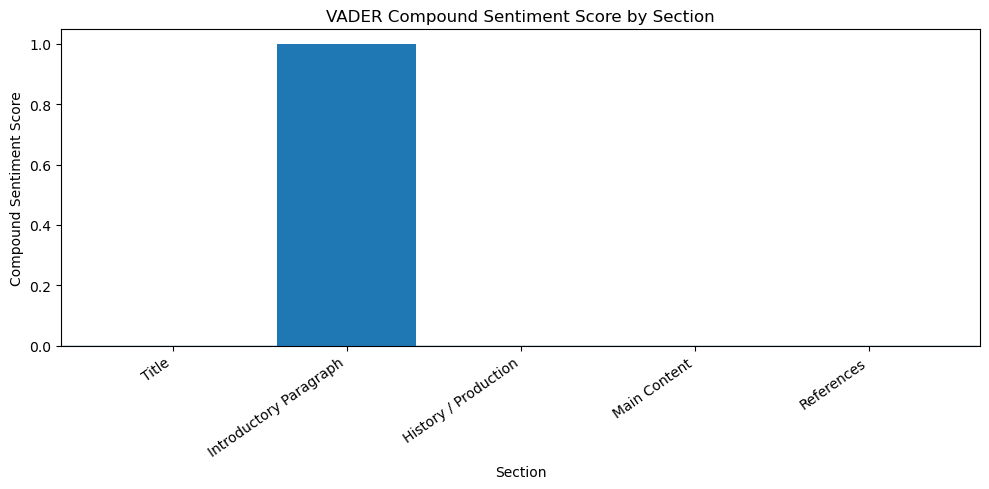

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(analysis_df["Section"], analysis_df["VADER_Compound"])
plt.axhline(0, linewidth=1)
plt.title("VADER Compound Sentiment Score by Section")
plt.xlabel("Section")
plt.ylabel("Compound Sentiment Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 10. Visualize positive, neutral, and negative scores

This chart shows that Wikipedia text is usually dominated by neutral language.


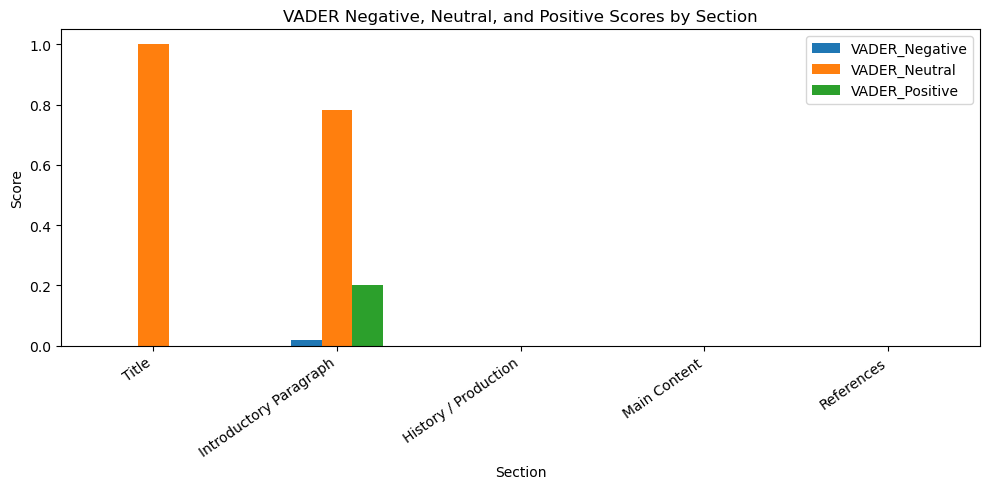

In [12]:
score_columns = ["VADER_Negative", "VADER_Neutral", "VADER_Positive"]

plot_df = analysis_df.set_index("Section")[score_columns]

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("VADER Negative, Neutral, and Positive Scores by Section")
plt.xlabel("Section")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 11. Visualize polarity over text order

Wikipedia does not provide review dates, so a true “polarity over time” chart is not possible from this article alone.  
Instead, I create a **polarity over text order** chart by analyzing sentences in the order they appear in the article. This works like a pseudo-time sequence.


In [13]:
sentence_rows = []

for section, text in sections.items():
    sentences = sent_tokenize(text)
    for i, sentence in enumerate(sentences):
        if len(sentence.split()) >= 5:
            vader_score = sia.polarity_scores(sentence)["compound"]
            blob_score = TextBlob(sentence).sentiment.polarity
            sentence_rows.append({
                "Section": section,
                "Sentence_Index": len(sentence_rows) + 1,
                "Sentence": sentence,
                "VADER_Compound": vader_score,
                "TextBlob_Polarity": blob_score
            })

sentence_df = pd.DataFrame(sentence_rows)
sentence_df["VADER_Rolling_Avg"] = sentence_df["VADER_Compound"].rolling(window=10, min_periods=1).mean()
sentence_df["TextBlob_Rolling_Avg"] = sentence_df["TextBlob_Polarity"].rolling(window=10, min_periods=1).mean()

sentence_df.head()


,Section,Sentence_Index,Sentence,VADER_Compound,TextBlob_Polarity,VADER_Rolling_Avg,TextBlob_Rolling_Avg
0,Introductory Paragraph,1,Titanic is a 1997 American epic historical rom...,0.5574,0.033333,0.557400,0.033333
1,Introductory Paragraph,2,Incorporating both historical and fictional as...,0.0000,0.000000,0.278700,0.016667
2,Introductory Paragraph,3,Leonardo DiCaprio and Kate Winslet star as mem...,0.6369,0.177778,0.398100,0.070370
3,Introductory Paragraph,4,"The ensemble cast includes Billy Zane , Kathy ...",0.0000,0.000000,0.298575,0.052778
4,Introductory Paragraph,5,Cameron's inspiration came from his fascinatio...,0.7650,0.000000,0.391860,0.042222


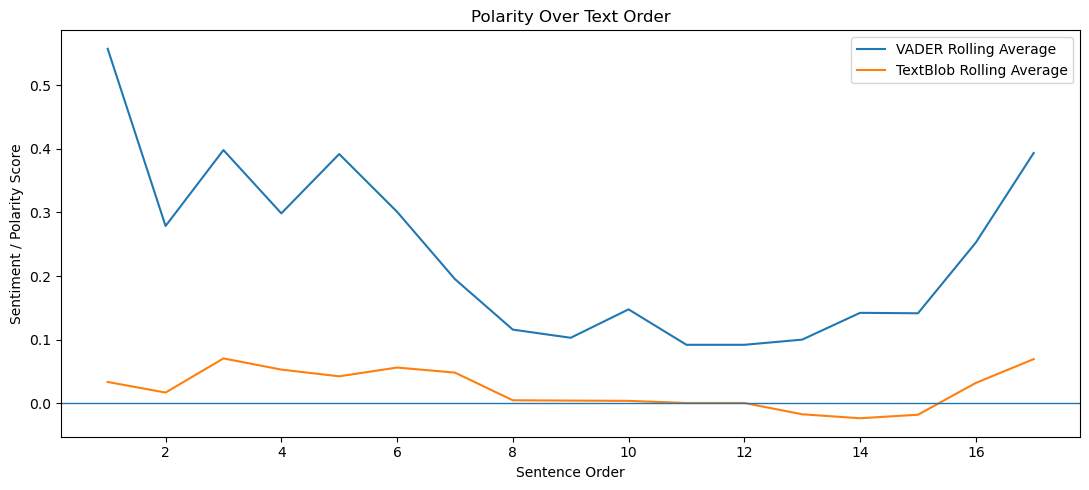

In [14]:
plt.figure(figsize=(11, 5))
plt.plot(sentence_df["Sentence_Index"], sentence_df["VADER_Rolling_Avg"], label="VADER Rolling Average")
plt.plot(sentence_df["Sentence_Index"], sentence_df["TextBlob_Rolling_Avg"], label="TextBlob Rolling Average")
plt.axhline(0, linewidth=1)
plt.title("Polarity Over Text Order")
plt.xlabel("Sentence Order")
plt.ylabel("Sentiment / Polarity Score")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Generate a WordCloud

The WordCloud shows frequent words from the extracted text.  
For Wikipedia, the WordCloud is more useful for **topic analysis** than emotional analysis because the article is written in an objective style.


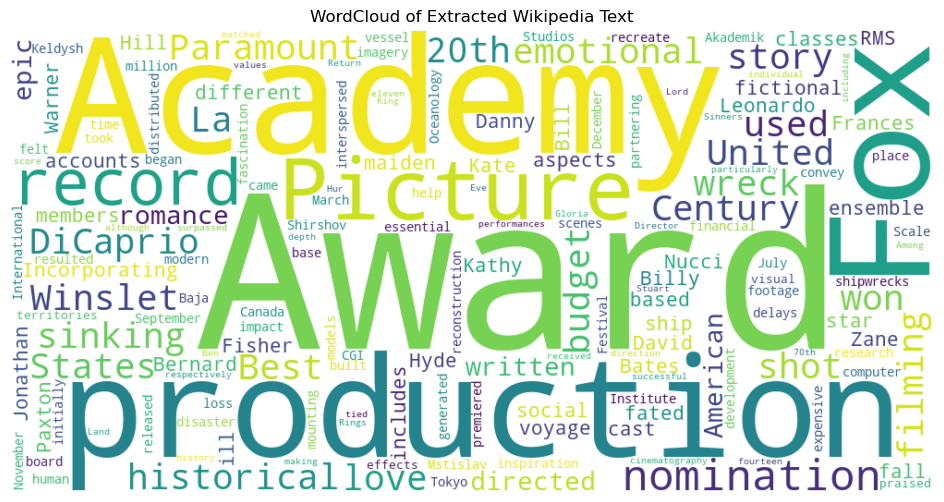

In [15]:
all_text = " ".join(sections.values())

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "film", "Titanic", "Cameron", "James", "Rose", "Jack", 
    "one", "also", "would", "made", "said"
])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Extracted Wikipedia Text")
plt.show()


## 13. Word frequency table

This gives a more exact version of the WordCloud by listing the most common words.


In [16]:
from collections import Counter

words = re.findall(r"\b[a-zA-Z]{4,}\b", all_text.lower())
words = [w for w in words if w not in custom_stopwords]

word_freq = Counter(words).most_common(20)
word_freq_df = pd.DataFrame(word_freq, columns=["Word", "Frequency"])
word_freq_df


,Word,Frequency
0,titanic,8
1,cameron,4
2,academy,4
3,production,3
4,awards,3
5,historical,2
6,sinking,2
7,dicaprio,2
8,winslet,2
9,love,2


## 14. Report / Discussion

### Extraction Summary

This project extracted five required parts from the Wikipedia article for *Titanic (1997 film)*. The title and introductory paragraphs were taken from the beginning of the article. Since the page does not have a section literally called “History,” the Production section was used as the history/background section because it explains the film’s development, filming process, production budget, and technical background. The main content section combined major article parts such as Plot, Cast, Release, Reception, Accolades, and Legacy. A sample of references was also extracted from the References section.

### Sentiment Analysis Summary

VADER was used as the main sentiment analysis tool. Since Wikipedia articles are usually written in an objective and factual tone, the neutral score is expected to be high. The compound scores may still show some positive or negative movement depending on the section. For example, the Reception and Accolades sections may show more positive sentiment because they include words related to praise, awards, success, and critical response. The Plot section may include more negative words because the story includes disaster, death, sinking, and loss.

### VADER and TextBlob Comparison

TextBlob was used as a comparison tool. The TextBlob polarity scores should generally be similar to VADER compound scores, although they may not match exactly because the two tools use different sentiment methods. TextBlob also provides subjectivity, which is useful for this project because Wikipedia should have lower subjectivity than review-based websites like Yelp.

### WordCloud Interpretation

The WordCloud mainly shows the important topics in the article rather than strong emotional words. This is because the source is an encyclopedia article, not customer reviews or social media comments. Words related to the movie, production, cast, release, and awards are expected to appear often.

### Limitation

A true “polarity over time” chart is difficult for this Wikipedia page because the article does not contain dated reviews. Therefore, this project uses sentence order as a pseudo-time sequence. If the goal were to analyze real opinion changes over time, a review dataset such as IMDb or Rotten Tomatoes reviews would be more appropriate.

### Conclusion

Overall, Wikipedia is a strong source for section extraction because it has a clear structure, but it is less emotional than review websites. VADER works well for this assignment because it gives clear negative, neutral, positive, and compound scores. TextBlob provides a useful comparison, especially through polarity and subjectivity scores. The results show that the article is mostly neutral, which matches the writing style of Wikipedia.
